# LSTM

In [1]:
import urllib.request

url = "https://www.gutenberg.org/files/2701/2701-0.txt"
text = urllib.request.urlretrieve(url, "moby_dick.txt")
with open("moby_dick.txt", encoding="utf-8") as f:
    text = f.read()


start = text.find("*** START OF")
end = text.find("*** END OF")
text = text[text.find("\n", start):end]
text = text[27157::]

In [2]:
import numpy as np
from collections import Counter

cut_len = 2**18 + 1
text = text
text = text[:cut_len]

count = Counter(text)

chars = sorted(set(text))
vocab = {c: i for i, c in enumerate(chars)}
inv_vocab = {i: c for c, i in vocab.items()}
vocab_size = len(vocab)

encoded = np.array([vocab[c] for c in text])
onehot = np.eye(vocab_size)[encoded]

seq_len = 32
x = onehot[:-1].reshape(-1, seq_len, vocab_size)
y = onehot[1:].reshape(-1, seq_len, vocab_size)

print(count)
print(f"Unique tokens: {vocab_size}")
print(f"Total tokens: {len(encoded)}")
print(f"x shape: {x.shape}")

Counter({' ': 42447, 'e': 24717, 't': 18214, 'a': 16611, 'o': 15514, 'n': 14270, 'i': 13034, 's': 13028, 'h': 12872, 'r': 10863, 'l': 8879, 'd': 8621, 'u': 5859, 'm': 5035, 'g': 4811, '\n': 4640, 'w': 4600, 'c': 4379, ',': 4244, 'f': 4194, 'p': 3709, 'y': 3617, 'b': 3169, 'v': 1736, 'k': 1710, '.': 1698, 'I': 1027, ';': 830, '’': 606, '-': 457, '“': 403, 'A': 401, '—': 398, 'q': 392, '”': 384, 'T': 359, 'B': 357, 'C': 305, 'H': 286, 'S': 284, '?': 257, '!': 249, 'P': 228, 'W': 204, 'j': 201, 'N': 192, 'Q': 189, 'x': 186, '_': 144, 'M': 128, 'E': 122, 'G': 111, 'F': 107, 'L': 99, 'J': 93, 'z': 91, 'D': 84, 'R': 81, 'O': 80, 'Y': 79, '0': 31, '‘': 26, ':': 23, '1': 22, '2': 20, 'K': 20, 'V': 17, 'U': 15, '(': 10, ')': 10, '3': 10, '7': 10, '5': 8, '8': 8, 'X': 6, 'Z': 5, '4': 4, '6': 4, '9': 4, '*': 3, '$': 2, '£': 1, 'æ': 1})
Unique tokens: 83
Total tokens: 262145
x shape: (8192, 32, 83)


In [3]:
from NNLibrary.network import Network
from NNLibrary.Layers.learnable import RNN, LSTM, LinearLayer
from NNLibrary.Layers.functional import Flatten

hidden_dim = 64

network = Network(
    layers=[
        LSTM(in_dim=vocab_size, hidden_dim=hidden_dim, out_dim=vocab_size),
        LSTM(in_dim=hidden_dim, hidden_dim=hidden_dim, out_dim=32),
        # Flatten(),
        LinearLayer(in_dim=hidden_dim, out_dim=vocab_size)
        # Sigmoid(),
        # Softmax(),
    ]
)

n_params = network.count_parameters()
print(f"Total parameter count: {n_params}")

Total parameter count: 76307


In [4]:
from NNLibrary.Layers.activations import Softmax

def sample_text(network, length=64, T=1, np_seed=None, seed=" "):
    np.random.seed(np_seed)
    softmax = Softmax(T=T)

    context = [onehot[vocab[seed]]] # List of one-hot

    out_seq = seed

    for _ in range(length):
        x_in = np.expand_dims(np.array(context), axis=0)
        logits = network.forward(x_in)
        pred = softmax.forward(logits)

        next_id = np.random.choice(vocab_size, p=pred[0, -1])
        next_ch = inv_vocab[next_id]

        out_seq += next_ch
        # print(onehot[inv_vocab[next_id]])
        context.append(onehot[next_id])

    print(out_seq)
    return out_seq

In [6]:
# TODO:
# Fix dataloader batches if not divisible by 2

Epoch 0
Loss: 2.8757597305713922
 aL a  bpb. i’ b e stnbtdpte,yueh ul ew n um dkw otc ms
iiev   Ne
Epoch 10
Loss: 1.9935237511046924
 ohptadnoCyeeeiicodhxsoan eorhrh
cnm aelne,falnaln yspeowanswrc d
Epoch 20
Loss: 1.8500398059180005
 oufdsDpeosBeogossiiaildowuoopam urn e i,oIteesiogioa i eogeiyie;


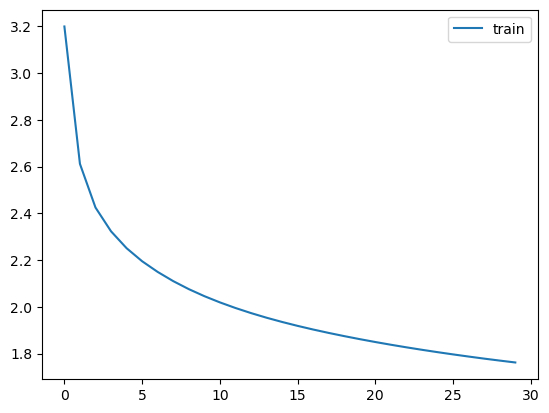

In [5]:
import matplotlib.pyplot as plt
from NNLibrary.Layers.loss import CrossEntropy, SoftmaxCE
from NNLibrary.optimizers import Adam, GradientDescent
from NNLibrary.data import DataLoader

batch_size = 32
dataloader = DataLoader(x, y, batch_size)
xb, yb = dataloader.get_batches()
n_batches = len(xb)

epochs = 30
lr = 0.001

loss_fn = SoftmaxCE()
optimizer = Adam(lr, beta=0.9, gamma=0.999)
# optimizr = GradientDescent(lr=lr)

metrics = {"train": {"loss": [], "epoch": []}, "val": {"loss": [], "epoch": []}, "epochs": []}

for epoch in range(epochs):
    network.train()
    metrics["epochs"].append(epoch)

    train_loss = 0
    for batch in range(n_batches):

        out = network.forward(xb[batch])
        loss = loss_fn.forward(out, yb[batch])
        train_loss += loss

        network.backprop(loss_fn, optimizer) # Backpropagation and weight updates
    dataloader.shuffle_batches()

    metrics["train"]["loss"].append(train_loss / n_batches)
    metrics["train"]["epoch"].append(epoch)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}")
        print(f"Loss: {loss}")
        out_seq = sample_text(network, T=1)


plt.plot(metrics["train"]["epoch"], metrics["train"]["loss"], label="train")
plt.legend()
plt.show()

In [9]:
out_seq = sample_text(network, length=64, T=1, seed=" ")


 e andmocfdwrasoswreeeadcu eyalsoofxpoogoeacswoctdwoteotootaspav,
